In [1]:
%matplotlib inline
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.counting import (
    simulate_measurement, net_rate, expected_relative_uncertainty,
    time_for_relative_uncertainty, distance_response, fit_distance_response,
    validation_ratio,
)

In [2]:
source_rate, bkg_rate = 20.0, 5.0   # counts/s (assumed values)
times = np.array([1, 3, 10, 30, 100, 300, 1000, 3000], dtype=float)

rows = []
for i, t in enumerate(times):
    gross, bkg = simulate_measurement(source_rate, bkg_rate, t, t, size=2000, seed=100 + i)
    net, _ = net_rate(gross, t, bkg, t)
    rows.append({
        "time (s)": t,
        "MC rel. unc. (%)": 100 * net.std(ddof=1) / source_rate,
        "analytic rel. unc. (%)": 100 * expected_relative_uncertainty(source_rate, bkg_rate, t, t),
    })
pd.DataFrame(rows).round(2)

,time (s),MC rel. unc. (%),analytic rel. unc. (%)
0,1.0,27.57,27.39
1,3.0,16.00,15.81
2,10.0,8.54,8.66
3,30.0,5.15,5.00
4,100.0,2.76,2.74
5,300.0,1.58,1.58
6,1000.0,0.89,0.87
7,3000.0,0.50,0.50


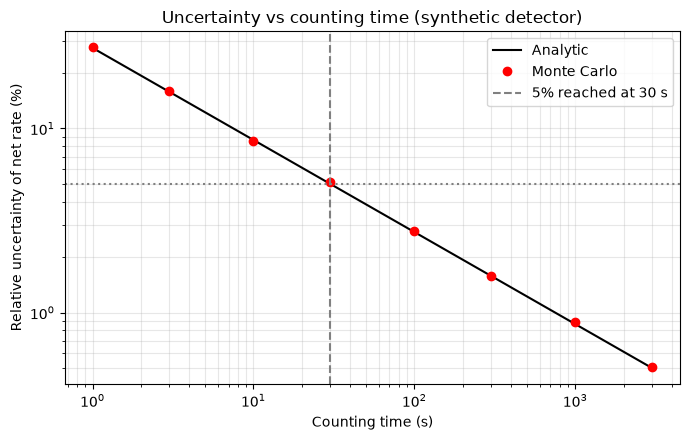

In [3]:
t_smooth = np.logspace(0, np.log10(3000), 100)
analytic = 100 * expected_relative_uncertainty(source_rate, bkg_rate, t_smooth, t_smooth)
t_target = time_for_relative_uncertainty(source_rate, bkg_rate, 0.05)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(t_smooth, analytic, "k-", label="Analytic")
ax.loglog(times, [r["MC rel. unc. (%)"] for r in rows], "ro", label="Monte Carlo")
ax.axhline(5, color="grey", linestyle=":")
ax.axvline(t_target, color="grey", linestyle="--", label=f"5% reached at {t_target:.0f} s")
ax.set_xlabel("Counting time (s)")
ax.set_ylabel("Relative uncertainty of net rate (%)")
ax.set_title("Uncertainty vs counting time (synthetic detector)")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig("../figures/uncertainty_vs_time.png", dpi=300)
plt.show()

In [4]:
pd.DataFrame([
    {"background (counts/s)": b,
     "time to reach 5% (s)": time_for_relative_uncertainty(20.0, b, 0.05)}
    for b in [0, 5, 20, 100]
])

,background (counts/s),time to reach 5% (s)
0,0,20.0
1,5,30.0
2,20,60.0
3,100,220.0


In [5]:
d = np.array([0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0])
TRUE = {"A": 500.0, "d0": 0.03, "B": 2.0}     # hidden true values
t_scan = 300.0

true_rate = distance_response(d, TRUE["A"], TRUE["d0"], TRUE["B"])
gross, bkg = simulate_measurement(true_rate, 1.0, t_scan, t_scan, size=len(d), seed=11)
rate, sigma = net_rate(gross, t_scan, bkg, t_scan)

popt, pcov, chi2, ndf = fit_distance_response(d, rate, sigma)
perr = np.sqrt(np.diag(pcov))
for name, val, err in zip(["A", "d0", "B"], popt, perr):
    lo, hi = val - 1.96 * err, val + 1.96 * err
    print(f"{name:3s} fit = {val:8.4f} +/- {1.96 * err:7.4f}   true = {TRUE[name]}   recovered: {lo <= TRUE[name] <= hi}")
print(f"chi2 = {chi2:.2f}, ndf = {ndf}, chi2/ndf = {chi2 / ndf:.2f}")

A   fit = 500.0335 +/-  4.3800   true = 500.0   recovered: True
d0  fit =   0.0304 +/-  0.0026   true = 0.03   recovered: True
B   fit =   1.9450 +/-  0.6478   true = 2.0   recovered: True
chi2 = 11.11, ndf = 5, chi2/ndf = 2.22


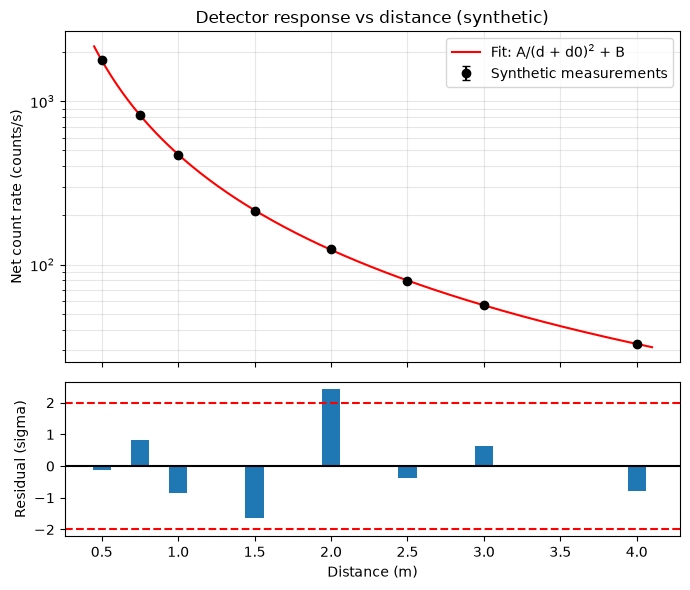

In [6]:
ds = np.linspace(0.45, 4.1, 200)
resid = (rate - distance_response(d, *popt)) / sigma

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.4]})
ax1.errorbar(d, rate, yerr=sigma, fmt="ko", capsize=3, label="Synthetic measurements")
ax1.plot(ds, distance_response(ds, *popt), "r-", label="Fit: A/(d + d0)$^2$ + B")
ax1.set_yscale("log")
ax1.set_ylabel("Net count rate (counts/s)")
ax1.set_title("Detector response vs distance (synthetic)")
ax1.legend()
ax1.grid(alpha=0.3, which="both")

ax2.bar(d, resid, width=0.12)
ax2.axhline(0, color="k")
ax2.axhline(2, color="r", linestyle="--")
ax2.axhline(-2, color="r", linestyle="--")
ax2.set_xlabel("Distance (m)")
ax2.set_ylabel("Residual (sigma)")
fig.tight_layout()
fig.savefig("../figures/distance_fit.png", dpi=300)
plt.show()

In [7]:
truth = np.array([TRUE["A"], TRUE["d0"], TRUE["B"]])
n_rep = 500
covered = np.zeros(3)
chi2_over_ndf = []

for k in range(n_rep):
    g, b = simulate_measurement(true_rate, 1.0, t_scan, t_scan, size=len(d), seed=1000 + k)
    r, s = net_rate(g, t_scan, b, t_scan)
    p, c, chi2_k, ndf_k = fit_distance_response(d, r, s)
    covered += np.abs(p - truth) <= 1.96 * np.sqrt(np.diag(c))
    chi2_over_ndf.append(chi2_k / ndf_k)

print("Fraction of repeats where the 95% interval contains the truth (A, d0, B):", covered / n_rep)
print(f"Mean chi2/ndf over repeats: {np.mean(chi2_over_ndf):.2f}")

Fraction of repeats where the 95% interval contains the truth (A, d0, B): [0.948 0.962 0.934]
Mean chi2/ndf over repeats: 1.05


In [8]:
H_ref, H_ref_rel = 50.0, 0.02    # reference dose rate (uSv/h) and its assumed 2% uncertainty
S_true = 0.4                      # true sensitivity (counts/s per uSv/h), hidden from the analysis
bkg_rate = 5.0
t_cal = 600.0

gross, bkg = simulate_measurement(S_true * H_ref, bkg_rate, t_cal, t_cal, seed=21)
R_cal, R_cal_sigma = net_rate(gross, t_cal, bkg, t_cal)

N = H_ref / R_cal                                    # calibration factor (uSv/h per count/s)
N_rel = np.sqrt(H_ref_rel**2 + (R_cal_sigma / R_cal)**2)
print(f"Calibration factor = {N:.3f} uSv/h per count/s, +/- {100 * N_rel:.1f}%   (true value {1 / S_true})")

Calibration factor = 2.485 uSv/h per count/s, +/- 2.3%   (true value 2.5)


In [9]:
H_test, t_test = 30.0, 600.0     # second field: true dose rate (reference known to the same 2%)
rows = []
for k, bias in enumerate([0.0, 0.03, 0.06, 0.10, 0.15]):    # true over-response, unknown to the analysis
    g, b = simulate_measurement(S_true * (1 + bias) * H_test, bkg_rate, t_test, t_test, seed=30 + k)
    R, R_sigma = net_rate(g, t_test, b, t_test)
    reading = N * R
    reading_sigma = reading * np.sqrt(N_rel**2 + (R_sigma / R)**2)
    ratio, ratio_sigma, z, agrees = validation_ratio(reading, reading_sigma, H_test, H_ref_rel * H_test)
    rows.append({
        "true over-response (%)": 100 * bias,
        "reading (uSv/h)": reading,
        "reading / reference": ratio,
        "uncertainty (%)": 100 * ratio_sigma / ratio,
        "z": z,
        "agrees": agrees,
    })
val = pd.DataFrame(rows)
val.round(3)

,true over-response (%),reading (uSv/h),reading / reference,uncertainty (%),z,agrees
0,0.0,29.839,0.995,3.429,-0.157,True
1,3.0,31.247,1.042,3.411,1.170,True
2,6.0,31.206,1.040,3.409,1.134,True
3,10.0,32.370,1.079,3.396,2.156,False
4,15.0,33.956,1.132,3.370,3.457,False


In [10]:
H_test, t_test = 30.0, 600.0     # second field: true dose rate (reference known to the same 2%)
rows = []
for k, bias in enumerate([0.0, 0.03, 0.06, 0.10, 0.15]):    # true over-response, unknown to the analysis
    g, b = simulate_measurement(S_true * (1 + bias) * H_test, bkg_rate, t_test, t_test, seed=30 + k)
    R, R_sigma = net_rate(g, t_test, b, t_test)
    reading = N * R
    reading_sigma = reading * np.sqrt(N_rel**2 + (R_sigma / R)**2)
    ratio, ratio_sigma, z, agrees = validation_ratio(reading, reading_sigma, H_test, H_ref_rel * H_test)
    rows.append({
        "true over-response (%)": 100 * bias,
        "reading (uSv/h)": reading,
        "reading / reference": ratio,
        "uncertainty (%)": 100 * ratio_sigma / ratio,
        "z": z,
        "agrees": agrees,
    })
val = pd.DataFrame(rows)
val.round(3)

,true over-response (%),reading (uSv/h),reading / reference,uncertainty (%),z,agrees
0,0.0,29.839,0.995,3.429,-0.157,True
1,3.0,31.247,1.042,3.411,1.170,True
2,6.0,31.206,1.040,3.409,1.134,True
3,10.0,32.370,1.079,3.396,2.156,False
4,15.0,33.956,1.132,3.370,3.457,False


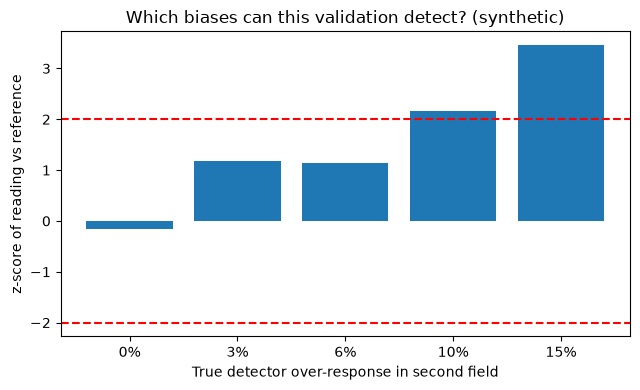

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([f"{b:.0f}%" for b in val["true over-response (%)"]], val["z"])
ax.axhline(2, color="r", linestyle="--")
ax.axhline(-2, color="r", linestyle="--")
ax.set_xlabel("True detector over-response in second field")
ax.set_ylabel("z-score of reading vs reference")
ax.set_title("Which biases can this validation detect? (synthetic)")
fig.tight_layout()
fig.savefig("../figures/validation_z_scores.png", dpi=300)
plt.show()

In [12]:
#Interpretation